1. 검출 : 저수준(형태)-중필터-고필터
2. 커널 크기에 따라 blur 효과가 달라짐
- 3*3 커널: 약간 흐림 (주변 9개 픽셀의 평균)
- 5*5 커널: 중간 흐림
- 11*11 커널: 많이 흐림
3. GaussianBlur(중앙 픽셀에 높은 가중치), medianBlur(outlier 제거)
4. 비지도학습은 threshold가 중요(기준!)
5. 모폴로지 연산
- 침식erosion:255(흰) 외곽 깎아내는 연산, 커널이 완전 흰색인 영역만 유지하고 나머지는 0->객체 작아지고 작은 노이즈 제거
- 팽창dialtion:255(흰) 넓혀줌, 커널이 1개라도 흰색 만나면 흰색->객체 팽창하고 끊김 영역 연결
- opening :erosion->dilation ->외부잡음 제거(제일 많이 씀)
- closing: 내부에 구멍 생기면 이거
- 둘 다 문제면 opening->closing

<openCV의 기하학적변환>
1. 필터: 주변 픽셀값 고려해서 새로운 픽셀값 계산하는 연산
CNN을 하기 위해 필요한 필터를 openCV에서 갖고옴!
블러, 엣지검출 등등

- 평균 필터 : 주변 픽셀들의 평균값으로 바꾸기(가중치 동일)
- 가우시안 필터 : 조금 더 자연스럽게 흐릿하게 만들어 주는 필터 예)프로필 사진 배경 흐리게 하기
- 중간값 필터(medain blur) : 잡티 제거(노이즈)
- 양방향 필터 : 가우시안 필터를 양쪽 방향으로 2번 시행, 경계선을 또렷하게 유지

sharpening / edge(경계, 윤곽선) detection
- 소벨(sobel) 필터: <기울기gradient> 1차 미분 기반. 어디가 경계지? 경계선을 찾아주는 필터(가로선, 세로선 따로 있는 경우 존재)
- 라플라시안 필터: <곡률, 변환점/2차 미분> 모든 방향의 경계선을 한번에 처리
- 캐니 엣지: <gradient+threshold>가장 정밀한 필터(윤곽선만 쏙쏙 뽑아내는 필터) ex) 만화 필터
```
CNN: 필터 학습.
라플라스 정리: 2차 미분
```

**1. 라플라시안 정의**
- 함수 값이 주변 값에 비해 얼마나 빠르게 변하는지 측정하기 위해 사용함
- 2차 미분(미분의 미분, 변화의 변화)

**2. 1차 미분 vs 2차 미분**
- 1차 미분(derivative): 기울기(slope)
  - 방향(direction) / 변화량(magnitude) 알려줌
- 2차 미분: 곡률(curvature) 측정
  - 함수가 얼마나 휘어지는가?
  - 주변 평균보다 큰가? 작은가? 판단
  - min/max 또는 변곡점 탐지
  
1차미분 : Gradient(기울기)
2차미분 : Gradient의 Divergence (Laplacian)

**이것만은 꼭!!**


회전
cv2.getRotationMatrix2D(중심점, 각도, 크기)
- 중심점(사진 한가운데) 기준, 각도만큼 회전해(돌려)
- 새 x좌표(x') = 기존 x * cos(각도) - 기존 y * sin(각도)
- 새 y좌표(y') = 기존 x * sin(각도) - 기존 y * cos(각도)
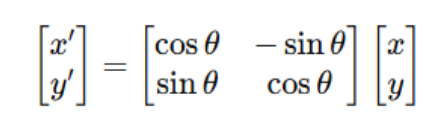
- cos과 sin이 왜 필요한가?
  - cos(각도) : 가로 방향으로 얼마나 이동하는지
  - sin(각도) : 세로 방향으로 얼마나 이동하는지
  - 각도 변화 = 그래프 내에서 가로세로 축이 반대가 됨
  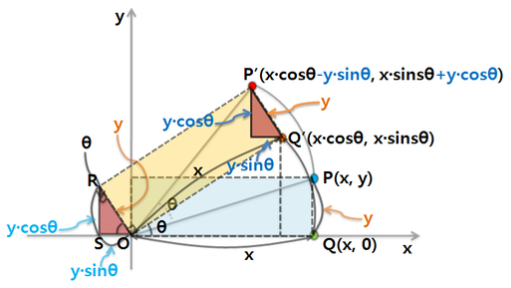

확대와 축소 (scaling)
- 이미지(사진) 크게 만들거나 작게 만드는 것
- 어라? 문제가 발생하네... (확대)하니깐 빈 공간이 생기네. 왜냐면 픽셀(pixel) 고정된 정해진 수니까

- 해결방법 (보간법, 간격을 보충해 줘야지)
  - nearest: 가장 가까운 픽셀 값 복사
    (단점: 계단 현상 발생, but 가장 많이 사용->초깃값으로 많이 사용한다)
    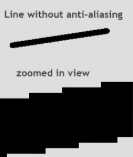
  - linear: 주변 픽셀들의 평균 사용
  - cubic: 더 부드럽게 (고급 보간법)
  - LANCZOS4 : 8*8 (최고품질, 매우 느림)

- 새 x = 기존 x * sx (s: 비율, sx>1이면 확대, sx<1이면 축소)
- 새 y = 기존 y × sy
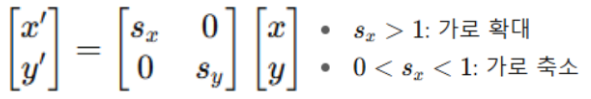

아핀 변환

- cv2.getAffineTransform(점1, 점2), 3개의 점으로 변환 지정
- 직선은 직선으로, 평행선은 계속 평행하게 유지
- 새 x = a₁₁×x + a₁₂×y + tx
- 새 y = a₂₁×x + a₂₂×y + ty

- a : 회전, 확대, 기울임
- t : 이동

자유도 (degree of freedom)
- 기준(default) 6DOF
- 위치이동 3가지(translation) : 앞뒤(surge), 좌우(sway), 위아래(heave) - x, y, z축
- 회전이동 3가지(rotation) 끄덕끄덕(pitch), 도리도리(yaw), 갸웃갸웃(roll) - x,y,z축 회전
- 객체(물체) 공간 안에서 얼마나 자유롭게 움직이느냐 또는 상태가 변하냐(변경 가능)
- 독립적으로 제어 가능한 움직임 수
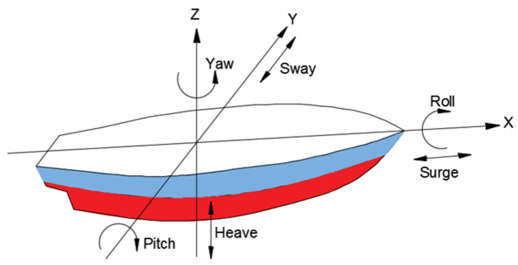

외웁시다. 제목 : 자유도(dof)
- 앞뒤 끄덕끄덕, 좌우 도리도리, 위아래 갸욱갸욱

c.f) 평면상(2D) 물체 자유도: 3DOF
왜냐햐면요 z축이 없자나요
- 앞뒤 (x축): (평면) 전진, 후진
- 좌우 (y축): (평면) 왼쪽, 오른쪽
- 평면회전(Yaw): 제자리 돌기

Perspective 변환(원근변환)
- **직선은 직선으로 유지**
- **평행선은 한 점(소실점)에서 만남**
- 예) 비스듬하게 찍은 사진 >> 정면으로 보이게, 원근감 있게
- 원본 사진에서 4개의 점 선택(사각형 모서리)
- 이 점들을 어디로 옮길지 결정

Cv2.getPerspectiveTransform(p1, p2)

p1: 원본 4개 점 / p2: 목표 4개 점

- 새 x = (h₁₁×x + h₁₂×y + h₁₃) / (h₃₁×x + h₃₂×y + h₃₃)
- 새 y = (h₂₁×x + h₂₂×y + h₂₃) / (h₃₁×x + h₃₂×y + h₃₃)

- 멀수록 분모(거리)가 커지고 나눈 값이 작아진다.
- 거꾸로 가까우면 분모가 작아지고 나눈 값이 커진다.


정리의 시간 : Affine(아핀) vs Perspective(원근)

1) 필요한 점
- 아핀: 3개 / 원근: 4개
2) 평행선
- 아핀: 평행 유지 / 원근 : 평행 깨짐(소실점-한점)
3) 사각형 형태
- 아핀: 평행사변형 / 원근: 사다리꼴


####정리
1. 확대 / 축소
- sx, sy >> 곱하기만 >> 크기가 변한다.
2. 회전
- 코가사세 >> sin(세로), cos(가로) >> 각도 변함
3. 아핀
- a(회전, 확대, 기울기), t(이동) 곱하고 더하기 >> 직선, 평행선 유지
4. 원근
- 나누기 추가 >> 평행선 깨짐(원근감 표현)

1. 선형 변환 (곱하기, 더하기만)
- 새로운 좌표 = 행렬(a) * 원래 좌표 + 이동(t)
  - 직선은 직선, 평행선은 평행
2. 비선형 변환 (나누기 포함)
- 새 좌표 = (행렬(a) * 원래 좌표) / 거리계수
  - 원근감perspective 표현